# Chapter 5 - Exercise 3: Phân tích dữ liệu Movies

#### Dữ liệu được lấy từ MovieLens website.
#### Download the Dataset
Theo link:
* **Data Source:** MovieLens web site (filename: ml-latest-small.zip)
* **Location:** https://grouplens.org/datasets/movielens/latest/

#### Thực hiện các yêu cầu sau, và đối chiếu với kết quả cho trước:

### Part 1: Đọc dữ liệu & Data Structures

##### Trong ml-latest-small.zip bao gồm 3 file CSV sau:
* **ratings.csv :** *userId*,*movieId*,*rating*, *timestamp* : Chứa dữ liệu về các xếp hạng của các bộ phim, mỗi dòng biểu thị một xếp hạng của một phim bởi một người dùng.
* **tags.csv :** *userId*,*movieId*, *tag*, *timestamp* : chứa thông tin về các Tag mà người dùng gắn vào cho phim, mỗi dòng biểu thị cho 1 tag của một người dùng cho một phim
* **movies.csv :** *movieId*, *title*, *genres* : chứa thông tin về các bộ phim, mỗi dòng biểu thị thông tin của 1 bộ phim <br>
##### Sử dụng  pd.read_csv() để đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Câu 1: Đọc file movies.csv => đưa dữ liệu vào movies
movies = pd.read_csv('movies.csv',sep = ',')
# Cho biết kiểu dữ liệu (type) của movies
print(type(movies))
# Cho biết kích thước (shape) của movies
print(movies.shape)
# Hiển thị 5 dòng dữ liệu đầu tiên (head) của movies
movies.head(5)

<class 'pandas.core.frame.DataFrame'>
(9125, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>&lt;class 'pandas.core.frame.DataFrame'&gt;
(9125, 3)
</pre>
    
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
    </tr>
    <tr>
      <th>1</th>
      <td>2</td>
      <td>Jumanji (1995)</td>
      <td>Adventure|Children|Fantasy</td>
    </tr>
    <tr>
      <th>2</th>
      <td>3</td>
      <td>Grumpier Old Men (1995)</td>
      <td>Comedy|Romance</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>Waiting to Exhale (1995)</td>
      <td>Comedy|Drama|Romance</td>
    </tr>
    <tr>
      <th>4</th>
      <td>5</td>
      <td>Father of the Bride Part II (1995)</td>
      <td>Comedy</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [3]:
# Hiển thị 5 dòng dữ liệu cuối (tail) của movies
movies.tail(5)

,movieId,title,genres
9120,162672,Mohenjo Daro (2016),Adventure|Drama|Romance
9121,163056,Shin Godzilla (2016),Action|Adventure|Fantasy|Sci-Fi
9122,163949,The Beatles: Eight Days a Week - The Touring Y...,Documentary
9123,164977,The Gay Desperado (1936),Comedy
9124,164979,"Women of '69, Unboxed",Documentary


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>9120</th>
      <td>162672</td>
      <td>Mohenjo Daro (2016)</td>
      <td>Adventure|Drama|Romance</td>
    </tr>
    <tr>
      <th>9121</th>
      <td>163056</td>
      <td>Shin Godzilla (2016)</td>
      <td>Action|Adventure|Fantasy|Sci-Fi</td>
    </tr>
    <tr>
      <th>9122</th>
      <td>163949</td>
      <td>The Beatles: Eight Days a Week - The Touring Y...</td>
      <td>Documentary</td>
    </tr>
    <tr>
      <th>9123</th>
      <td>164977</td>
      <td>The Gay Desperado (1936)</td>
      <td>Comedy</td>
    </tr>
    <tr>
      <th>9124</th>
      <td>164979</td>
      <td>Women of '69, Unboxed</td>
      <td>Documentary</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [4]:
# Cho biết kiểu dữ liệu (dtype) của các cột của movies
movies.dtypes

,0
movieId,int64
title,object
genres,object


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>movieId     int64
title      object
genres     object
dtype: object</pre>
  
</details>

In [5]:
# Xem thông tin (info) của movies
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9125 non-null   int64 
 1   title    9125 non-null   object
 2   genres   9124 non-null   object
dtypes: int64(1), object(2)
memory usage: 214.0+ KB


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>&lt;class 'pandas.core.frame.DataFrame'&gt;
RangeIndex: 9125 entries, 0 to 9124
Data columns (total 3 columns):
movieId    9125 non-null int64
title      9125 non-null object
genres     9124 non-null object
dtypes: int64(1), object(2)
memory usage: 214.0+ KB
</pre>
  
</details>

In [6]:
# Câu 2: Đọc file tags.csv => đưa dữ liệu vào tags #truoc khi doc du lieu kiem tra xem co nen bo id hay khong
tags = pd.read_csv('tags.csv',sep =',')
# Cho biết kiểu dữ liệu (type) của tags
print(type(tags))
# Cho biết kích thước (shape) của tags
print(tags.shape)
# Hiển thị 5 dòng đầu tiên (head) của tags
tags.head(5)

<class 'pandas.core.frame.DataFrame'>
(1296, 4)


,userId,movieId,tag,timestamp
0,15,339,sandra 'boring' bullock,1.138538e+09
1,15,1955,dentist,1.193435e+09
2,15,7478,Cambodia,1.170561e+09
3,15,32892,Russian,1.170626e+09
4,15,34162,forgettable,1.141392e+09


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>&lt;class 'pandas.core.frame.DataFrame'&gt;
(1296, 4)
</pre>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>tag</th>
      <th>timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>15</td>
      <td>339</td>
      <td>sandra 'boring' bullock</td>
      <td>1138537770</td>
    </tr>
    <tr>
      <th>1</th>
      <td>15</td>
      <td>1955</td>
      <td>dentist</td>
      <td>1193435061</td>
    </tr>
    <tr>
      <th>2</th>
      <td>15</td>
      <td>7478</td>
      <td>Cambodia</td>
      <td>1170560997</td>
    </tr>
    <tr>
      <th>3</th>
      <td>15</td>
      <td>32892</td>
      <td>Russian</td>
      <td>1170626366</td>
    </tr>
    <tr>
      <th>4</th>
      <td>15</td>
      <td>34162</td>
      <td>forgettable</td>
      <td>1141391765</td>
    </tr>
  </tbody>
</table>
</div>
</details>

In [7]:
# Hiển thị 5 dòng dữ liệu cuối (tail) của tags
tags.tail(5)

,userId,movieId,tag,timestamp
1291,660,135518,meaning of life,1.436681e+09
1292,660,135518,philosophical,1.436681e+09
1293,660,135518,sci-fi,1.436681e+09
1294,663,260,action,1.438398e+09
1295,663,260,Syfy,1.438398e+09


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>tag</th>
      <th>timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1291</th>
      <td>660</td>
      <td>135518</td>
      <td>meaning of life</td>
      <td>1436680885</td>
    </tr>
    <tr>
      <th>1292</th>
      <td>660</td>
      <td>135518</td>
      <td>philosophical</td>
      <td>1436680885</td>
    </tr>
    <tr>
      <th>1293</th>
      <td>660</td>
      <td>135518</td>
      <td>sci-fi</td>
      <td>1436680885</td>
    </tr>
    <tr>
      <th>1294</th>
      <td>663</td>
      <td>260</td>
      <td>action</td>
      <td>1438398078</td>
    </tr>
    <tr>
      <th>1295</th>
      <td>663</td>
      <td>260</td>
      <td>Syfy</td>
      <td>1438398050</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [8]:
# Cho biết kiểu dữ liệu (dtype) của các cột của tags
tags.dtypes

,0
userId,int64
movieId,int64
tag,object
timestamp,float64


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>userId        int64
movieId       int64
tag          object
timestamp    object
dtype: object</pre>
  
</details>

In [9]:
# Xem thông tin (info) của tags
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     1296 non-null   int64  
 1   movieId    1296 non-null   int64  
 2   tag        1296 non-null   object 
 3   timestamp  1295 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 40.6+ KB


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>&lt;class 'pandas.core.frame.DataFrame'&gt;
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 4 columns):
userId       1296 non-null int64
movieId      1296 non-null int64
tag          1296 non-null object
timestamp    1295 non-null object
dtypes: int64(2), object(2)
memory usage: 40.6+ KB
</pre>
  
</details>

In [10]:
# Câu 3: Đọc file ratings.csv => đưa dữ liệu vào ratings
ratings = pd.read_csv('ratings.csv',sep = ',')
# Cho biết kiểu dữ liệu (type) của ratings
type(ratings)
# Cho biết kích thước của ratings
ratings.shape
# Hiển thị 5 dòng đầu tiên (head) của ratings
ratings.head(5)

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>&lt;class 'pandas.core.frame.DataFrame'&gt;
(100004, 4)
</pre>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>rating</th>
      <th>timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>31</td>
      <td>2.5</td>
      <td>1260759144</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1</td>
      <td>1029</td>
      <td>3.0</td>
      <td>1260759179</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1</td>
      <td>1061</td>
      <td>3.0</td>
      <td>1260759182</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1</td>
      <td>1129</td>
      <td>2.0</td>
      <td>1260759185</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1</td>
      <td>1172</td>
      <td>4.0</td>
      <td>1260759205</td>
    </tr>
  </tbody>
</table>
</div>
</details>

In [11]:
# Hiển thị 5 dòng dữ liệu cuối (tail) của ratings
ratings.tail(5)

,userId,movieId,rating,timestamp
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663
100003,671,6565,3.5,1074784724


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>rating</th>
      <th>timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>99999</th>
      <td>671</td>
      <td>6268</td>
      <td>2.5</td>
      <td>1065579370</td>
    </tr>
    <tr>
      <th>100000</th>
      <td>671</td>
      <td>6269</td>
      <td>4.0</td>
      <td>1065149201</td>
    </tr>
    <tr>
      <th>100001</th>
      <td>671</td>
      <td>6365</td>
      <td>4.0</td>
      <td>1070940363</td>
    </tr>
    <tr>
      <th>100002</th>
      <td>671</td>
      <td>6385</td>
      <td>2.5</td>
      <td>1070979663</td>
    </tr>
    <tr>
      <th>100003</th>
      <td>671</td>
      <td>6565</td>
      <td>3.5</td>
      <td>1074784724</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [12]:
# Cho biết kiểu dữ liệu (dtype) của các cột của ratings
ratings.dtypes

,0
userId,int64
movieId,int64
rating,float64
timestamp,int64


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>userId         int64
movieId        int64
rating       float64
timestamp     object
dtype: object</pre>
  
</details>

In [13]:
# Xem thông tin (info) của ratings
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>&lt;class 'pandas.core.frame.DataFrame'&gt;
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
userId       100004 non-null int64
movieId      100004 non-null int64
rating       100004 non-null float64
timestamp    100004 non-null object
dtypes: float64(1), int64(2), object(1)
memory usage: 3.1+ MB
</pre>
  
</details>

### Part 2: Xử lý dữ liệu bị thiếu/ không hợp lệ

In [21]:
# Câu 1: Cho biết trong movies có dữ liệu null hay không? Nếu có loại bỏ dòng có dữ liệu null.
movies.isnull().any().any()

np.False_

<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>movieId    False
title      False
genres      True
dtype: bool</pre>
  
</details>

In [22]:
# Loại bỏ dòng có dữ liệu null
movies.dropna(subset=['genres'],axis= 0,inplace= True)
 #movies = movies.dropna(subset=['genres'],axis= 0)

In [23]:
# Câu 2: Cho biết trong ratings có dữ liệu null hay không? Nếu có loại bỏ dòng có dữ liệu null.
ratings.isnull().any()

,0
userId,False
movieId,False
rating,False
timestamp,False


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>userId       False
movieId      False
rating       False
timestamp    False
dtype: bool</pre>
  
 <p>Trong ratings không có giá trị NULL.</p>
</details>

In [24]:
# Câu 3: Cho biết trong tags có dữ liệu null hay không? Nếu có loại bỏ dòng có dữ liệu null.
tags.isnull().any().any()

np.True_

<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>userId       False
movieId      False
tag          False
timestamp     True
dtype: bool</pre>
  
</details>

In [25]:
#kiem tra bao nhieu dong du lieu null o cot timestap. Neu it qua thi co the bo, neu nhieu thi nen dien du lieu vao
tags['timestamp'].isnull().sum()
# Loại bỏ dòng có dữ liệu null
tags = tags.dropna(subset=['timestamp'],axis= 0)
tags.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1295 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   userId     1295 non-null   int64  
 1   movieId    1295 non-null   int64  
 2   tag        1295 non-null   object 
 3   timestamp  1295 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 50.6+ KB


In [26]:
from os import replace
# Câu 4: Kiểm tra xem có dữ liệu rating nào không hợp lệ hay không ('rating' > 5 hoặc 'rating' < 0) ?
# Nếu có, hãy thay bằng giá trị xuất hiện nhiều nhất
#B1 select rating from ratings where rating > 5 or rating < 0
ratings.loc[( ratings['rating'] > 5) | (ratings['rating'] < 0 ) , 'rating' ]
#B2 Tim ra gia tri xuat hien nhieu nhat cua cot rating
ratings.loc[:, 'rating'].mode()
#B3 Thay gia tri xuat hien nhieu nhat cho gia tri sai o tren
ratings.loc[( ratings['rating'] > 5) | (ratings['rating'] < 0 ) , 'rating' ] = ratings.loc[:,'rating'].mode()


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>True</pre>
  
</details>

### Part 3: Gộp DataFrame

In [27]:
# Câu 1: Tạo movies_tags bằng cách gộp dữ liệu của movies và tags theo cột chung là 'moviedId'.
movies_tags = pd.merge(movies,tags,on='movieId',how='inner')
# Hiển thị 5 dòng đầu của movies_tags
movies_tags.head(5)

,movieId,title,genres,userId,tag,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,501,Pixar,1.292956e+09
1,5,Father of the Bride Part II (1995),Comedy,431,steve martin,1.140455e+09
2,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,364,biblical,1.444535e+09
3,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,364,crime,1.444535e+09
4,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,364,dark,1.444535e+09


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>userId</th>
      <th>tag</th>
      <th>timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>501</td>
      <td>Pixar</td>
      <td>1292956344</td>
    </tr>
    <tr>
      <th>1</th>
      <td>5</td>
      <td>Father of the Bride Part II (1995)</td>
      <td>Comedy</td>
      <td>431</td>
      <td>steve martin</td>
      <td>1140455432</td>
    </tr>
    <tr>
      <th>2</th>
      <td>47</td>
      <td>Seven (a.k.a. Se7en) (1995)</td>
      <td>Mystery|Thriller</td>
      <td>364</td>
      <td>biblical</td>
      <td>1444534976</td>
    </tr>
    <tr>
      <th>3</th>
      <td>47</td>
      <td>Seven (a.k.a. Se7en) (1995)</td>
      <td>Mystery|Thriller</td>
      <td>364</td>
      <td>crime</td>
      <td>1444534982</td>
    </tr>
    <tr>
      <th>4</th>
      <td>47</td>
      <td>Seven (a.k.a. Se7en) (1995)</td>
      <td>Mystery|Thriller</td>
      <td>364</td>
      <td>dark</td>
      <td>1444534994</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [28]:
# Câu 2: Tạo movies_ratings bằng cách gộp dữ liệu của movies và ratings theo cột chung là 'moviedId'.
movies_ratings = pd.merge(movies,ratings,on='movieId',how='inner')
# Hiển thị 5 dòng đầu của movies_ratings
movies_ratings.head(5)

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,3.0,851866703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,9,4.0,938629179
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,13,5.0,1331380058
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.0,997938310
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,19,3.0,855190091


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>userId</th>
      <th>rating</th>
      <th>timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>7.0</td>
      <td>3.0</td>
      <td>851866703</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>9.0</td>
      <td>4.0</td>
      <td>938629179</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>13.0</td>
      <td>5.0</td>
      <td>1331380058</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>15.0</td>
      <td>2.0</td>
      <td>997938310</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>19.0</td>
      <td>3.0</td>
      <td>855190091</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

### Part 4: Lọc dữ liệu theo yêu cầu

In [29]:
# Câu 1: Tạo dataframe tag_counts cho biết với mỗi tag là có bao nhiêu film chứa giá trị 'tag' đó
# gợi ý: dùng tags['tag'].value_counts()
tag_counts = tags['tag'].value_counts()
# Hiển thị 10 dòng đầu của tag_counts
tag_counts.head(10)

,count
tag,
getdvd,33
Ei muista,29
tivo,26
toplist07,26
toplist11,20
toplist12,20
tcm,20
toplist08,19
toplist15,19


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>tag</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>getdvd</th>
      <td>33</td>
    </tr>
    <tr>
      <th>Ei muista</th>
      <td>29</td>
    </tr>
    <tr>
      <th>toplist07</th>
      <td>26</td>
    </tr>
    <tr>
      <th>tivo</th>
      <td>26</td>
    </tr>
    <tr>
      <th>tcm</th>
      <td>20</td>
    </tr>
    <tr>
      <th>toplist12</th>
      <td>20</td>
    </tr>
    <tr>
      <th>toplist11</th>
      <td>20</td>
    </tr>
    <tr>
      <th>toplist15</th>
      <td>19</td>
    </tr>
    <tr>
      <th>toplist08</th>
      <td>19</td>
    </tr>
    <tr>
      <th>toplist10</th>
      <td>18</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [30]:
# Câu 2: Tạo is_highly_rated theo điều kiện: có 'rating' >= 4.0 của dataframe ratings
ratings.loc[ratings['rating'] > 4.0 ,'is_highly_rated'] = True
# Hiển thị 5 dòng dữ liệu đầu của is_highly_rated
ratings.head(5)

,userId,movieId,rating,timestamp,is_highly_rated
0,1,31,2.5,1260759144,NaN
1,1,1029,3.0,1260759179,NaN
2,1,1061,3.0,1260759182,NaN
3,1,1129,2.0,1260759185,NaN
4,1,1172,4.0,1260759205,NaN


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>0    False
1    False
2    False
3    False
4     True
Name: rating, dtype: bool</pre>
  
</details>

In [31]:
# Liệt kê các phim thỏa is_highly_rated


In [33]:
# Liệt kê các phim thỏa is_highly_rated
# The error 'NameError: name 'is_highly_rated' is not defined' occurs because
# in the previous cell, 'is_highly_rated' was created as a new column within the 'ratings' DataFrame,
# not as a standalone DataFrame or Series.
# To fix this, we first filter the 'ratings' DataFrame to select the highly rated entries.
# Based on the problem description ("rating' >= 4.0") and the example output,
# we should filter for ratings that are 4.0 or greater.
highly_rated_films_data = ratings[ratings['rating'] >= 4.0]
# Then, we merge this filtered data with the 'movies' DataFrame to get the movie details.
movies_hightly_rated = pd.merge(movies, highly_rated_films_data, on='movieId')
movies_hightly_rated

,movieId,title,genres,userId,rating,timestamp,is_highly_rated
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,9,4.0,938629179,NaN
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,13,5.0,1331380058,True
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,26,5.0,1360087980,True
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,30,4.0,944943070,NaN
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,37,4.0,981308121,NaN
...,...,...,...,...,...,...,...
51554,160718,Piper (2016),Animation,547,4.0,1469713151,NaN
51555,161944,The Last Brickmaker in America (2001),Drama,287,5.0,1470167824,True
51556,162376,Stranger Things,Drama,73,4.5,1474255532,True
51557,162542,Rustom (2016),Romance|Thriller,611,5.0,1471520667,True


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>rating</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>4</th>
      <td>1172.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>12</th>
      <td>1953.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>13</th>
      <td>2105.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>20</th>
      <td>10.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>21</th>
      <td>17.0</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>...</th>
      <td>...</td>
      <td>...</td>
    </tr>
    <tr>
      <th>99995</th>
      <td>5989.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>99996</th>
      <td>5991.0</td>
      <td>4.5</td>
    </tr>
    <tr>
      <th>99997</th>
      <td>5995.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>100000</th>
      <td>6269.0</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>100001</th>
      <td>6365.0</td>
      <td>4.0</td>
    </tr>
  </tbody>
</table>
<p>51568 rows × 2 columns</p>
</div>
  
</details>

In [44]:
# Câu 3: Tạo is_animation theo điều kiện trong cột genres của movies có chứa chuỗi 'Animation'
movies.loc[:, 'is_animation'] = movies['genres'].str.contains('Animation')
# Hiển thị 5 dòng dữ liệu đầu của is_animation
movies.head(5)

,movieId,title,genres,is_animation
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True
1,2,Jumanji (1995),Adventure|Children|Fantasy,False
2,3,Grumpier Old Men (1995),Comedy|Romance,False
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,False
4,5,Father of the Bride Part II (1995),Comedy,False


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>0     True
1    False
2    False
3    False
4    False
Name: genres, dtype: bool</pre>
  
</details>

In [ ]:
# Liệt kê các phim thỏa is_animation

<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
    </tr>
    <tr>
      <th>12</th>
      <td>13</td>
      <td>Balto (1995)</td>
      <td>Adventure|Animation|Children</td>
    </tr>
    <tr>
      <th>46</th>
      <td>48</td>
      <td>Pocahontas (1995)</td>
      <td>Animation|Children|Drama|Musical|Romance</td>
    </tr>
    <tr>
      <th>211</th>
      <td>239</td>
      <td>Goofy Movie, A (1995)</td>
      <td>Animation|Children|Comedy|Romance</td>
    </tr>
    <tr>
      <th>216</th>
      <td>244</td>
      <td>Gumby: The Movie (1995)</td>
      <td>Animation|Children</td>
    </tr>
    <tr>
      <th>...</th>
      <td>...</td>
      <td>...</td>
      <td>...</td>
    </tr>
    <tr>
      <th>9070</th>
      <td>152081</td>
      <td>Zootopia (2016)</td>
      <td>Action|Adventure|Animation|Children|Comedy</td>
    </tr>
    <tr>
      <th>9079</th>
      <td>156025</td>
      <td>Ice Age: The Great Egg-Scapade (2016)</td>
      <td>Adventure|Animation|Children|Comedy</td>
    </tr>
    <tr>
      <th>9085</th>
      <td>157296</td>
      <td>Finding Dory (2016)</td>
      <td>Adventure|Animation|Comedy</td>
    </tr>
    <tr>
      <th>9108</th>
      <td>160718</td>
      <td>Piper (2016)</td>
      <td>Animation</td>
    </tr>
    <tr>
      <th>9114</th>
      <td>161594</td>
      <td>Kingsglaive: Final Fantasy XV (2016)</td>
      <td>Action|Adventure|Animation|Drama|Fantasy|Sci-Fi</td>
    </tr>
  </tbody>
</table>
<p>447 rows × 3 columns</p>
</div>
  
</details>

In [45]:
# Câu 4: Tạo movie_genres từ cột 'genres' bằng cách tách cột 'genres' dựa vào ký tự '|'
movies_genres = movies['genres'].str.split('|',expand= True)
# Hiển thị 10 dòng cuối của movie_genres
movies_genres.tail(10)

,0,1,2,3,4,5,6,7,8,9
9115,Drama,Horror,Thriller,None,None,None,None,None,None,None
9116,Action,Adventure,Horror,Sci-Fi,None,None,None,None,None,None
9117,Drama,None,None,None,None,None,None,None,None,None
9118,Drama,None,None,None,None,None,None,None,None,None
9119,Romance,Thriller,None,None,None,None,None,None,None,None
9120,Adventure,Drama,Romance,None,None,None,None,None,None,None
9121,Action,Adventure,Fantasy,Sci-Fi,None,None,None,None,None,None
9122,Documentary,None,None,None,None,None,None,None,None,None
9123,Comedy,None,None,None,None,None,None,None,None,None
9124,Documentary,None,None,None,None,None,None,None,None,None


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>0</th>
      <th>1</th>
      <th>2</th>
      <th>3</th>
      <th>4</th>
      <th>5</th>
      <th>6</th>
      <th>7</th>
      <th>8</th>
      <th>9</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>9115</th>
      <td>Drama</td>
      <td>Horror</td>
      <td>Thriller</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9116</th>
      <td>Action</td>
      <td>Adventure</td>
      <td>Horror</td>
      <td>Sci-Fi</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9117</th>
      <td>Drama</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9118</th>
      <td>Drama</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9119</th>
      <td>Romance</td>
      <td>Thriller</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9120</th>
      <td>Adventure</td>
      <td>Drama</td>
      <td>Romance</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9121</th>
      <td>Action</td>
      <td>Adventure</td>
      <td>Fantasy</td>
      <td>Sci-Fi</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9122</th>
      <td>Documentary</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9123</th>
      <td>Comedy</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
    <tr>
      <th>9124</th>
      <td>Documentary</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [51]:
# Câu 5: Thêm cột mới cho movie_genres có tên là 'isComedy',
# giá trị là True nếu trong movies['genres'] có chứa chuỗi 'Comedy', ngược lại là False
movies['isComedy'] = movies['genres'].str.contains('Comedy')
# Hiển thị 10 dòng đầu của movie_genres
movies.head(10)

,movieId,title,genres,is_animation,isComedy
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True
1,2,Jumanji (1995),Adventure|Children|Fantasy,False,False
2,3,Grumpier Old Men (1995),Comedy|Romance,False,True
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,False,True
4,5,Father of the Bride Part II (1995),Comedy,False,True
5,6,Heat (1995),Action|Crime|Thriller,False,False
6,7,Sabrina (1995),Comedy|Romance,False,True
7,8,Tom and Huck (1995),Adventure|Children,False,False
8,9,Sudden Death (1995),Action,False,False
9,10,GoldenEye (1995),Action|Adventure|Thriller,False,False


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>0</th>
      <th>1</th>
      <th>2</th>
      <th>3</th>
      <th>4</th>
      <th>5</th>
      <th>6</th>
      <th>7</th>
      <th>8</th>
      <th>9</th>
      <th>isComedy</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Adventure</td>
      <td>Animation</td>
      <td>Children</td>
      <td>Comedy</td>
      <td>Fantasy</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>True</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Adventure</td>
      <td>Children</td>
      <td>Fantasy</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>False</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Comedy</td>
      <td>Romance</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>True</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Comedy</td>
      <td>Drama</td>
      <td>Romance</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>True</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Comedy</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>True</td>
    </tr>
    <tr>
      <th>5</th>
      <td>Action</td>
      <td>Crime</td>
      <td>Thriller</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>False</td>
    </tr>
    <tr>
      <th>6</th>
      <td>Comedy</td>
      <td>Romance</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>True</td>
    </tr>
    <tr>
      <th>7</th>
      <td>Adventure</td>
      <td>Children</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>False</td>
    </tr>
    <tr>
      <th>8</th>
      <td>Action</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>False</td>
    </tr>
    <tr>
      <th>9</th>
      <td>Action</td>
      <td>Adventure</td>
      <td>Thriller</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>None</td>
      <td>False</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [58]:
# Câu 6: Thêm cột mới cho movies có tên là 'year' với year được lấy ra từ cột 'title'
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)')
# Hiển thị 5 dòng dữ liệu đầu của movies
movies.head(5)

,movieId,title,genres,is_animation,isComedy,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,False,False,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,False,True,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,False,True,1995
4,5,Father of the Bride Part II (1995),Comedy,False,True,1995


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>year</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>1995</td>
    </tr>
    <tr>
      <th>1</th>
      <td>2</td>
      <td>Jumanji (1995)</td>
      <td>Adventure|Children|Fantasy</td>
      <td>1995</td>
    </tr>
    <tr>
      <th>2</th>
      <td>3</td>
      <td>Grumpier Old Men (1995)</td>
      <td>Comedy|Romance</td>
      <td>1995</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>Waiting to Exhale (1995)</td>
      <td>Comedy|Drama|Romance</td>
      <td>1995</td>
    </tr>
    <tr>
      <th>4</th>
      <td>5</td>
      <td>Father of the Bride Part II (1995)</td>
      <td>Comedy</td>
      <td>1995</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

### Part 5: Thống kê dữ liệu

In [34]:
# Câu 1: Thực hiện thống kê chung dữ liệu ratings
ratings.describe()

,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100003.000000,1.000040e+05
mean,347.011310,12548.664363,3.543604,1.129639e+09
std,195.163838,26369.198969,1.058068,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>rating</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>count</th>
      <td>100004.000000</td>
      <td>100004.000000</td>
      <td>100004.000000</td>
    </tr>
    <tr>
      <th>mean</th>
      <td>347.011330</td>
      <td>12548.660904</td>
      <td>3.543608</td>
    </tr>
    <tr>
      <th>std</th>
      <td>195.163803</td>
      <td>26369.200592</td>
      <td>1.058064</td>
    </tr>
    <tr>
      <th>min</th>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0.500000</td>
    </tr>
    <tr>
      <th>25%</th>
      <td>182.000000</td>
      <td>1028.000000</td>
      <td>3.000000</td>
    </tr>
    <tr>
      <th>50%</th>
      <td>367.000000</td>
      <td>2406.500000</td>
      <td>4.000000</td>
    </tr>
    <tr>
      <th>75%</th>
      <td>520.000000</td>
      <td>5418.000000</td>
      <td>4.000000</td>
    </tr>
    <tr>
      <th>max</th>
      <td>671.000000</td>
      <td>163949.000000</td>
      <td>5.000000</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [36]:
# Câu 2: In giá trị trung bình, giá trị lớn nhất, giá trị nhỏ nhất,
#        độ lệch chuẩn, giá trị có tuần suất xuất hiện nhiều nhất của cột 'rating'
display( ratings.loc[: , 'rating'].mean())
display( ratings.loc[: , 'rating'].max())
display( ratings.loc[: , 'rating'].min())
display( ratings.loc[: , 'rating'].std())
display( ratings.loc[: , 'rating'].mode())

np.float64(3.5436036918892433)

5.0

0.5

1.05806841500883

,rating
0,4.0


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>Giá trị trung bình của ratings:  3.543608255669773
Giá trị nhỏ nhất của ratings:  0.5
Giá trị lớn nhất của ratings:  5.0
Độ lệch chuẩn của ratings:  1.0580641091070389
Giá trị có tần suất xuất hiện nhiều nhất của ratings:  4.0
</pre>
  
</details>

In [38]:
# Câu 3: Thống kê đếm số lượng phim theo ‘rating’ (Count of films). Xem kết quả.
ratings.groupby('rating')['movieId'].count()
# Xem kết quả


,movieId
rating,
0.5,1101
1.0,3326
1.5,1687
2.0,7271
2.5,4449
3.0,20064
3.5,10538
4.0,28749
4.5,7723


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>rating</th>
      <th>Count of films</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0.5</td>
      <td>1101</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1.0</td>
      <td>3326</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1.5</td>
      <td>1687</td>
    </tr>
    <tr>
      <th>3</th>
      <td>2.0</td>
      <td>7268</td>
    </tr>
    <tr>
      <th>4</th>
      <td>2.5</td>
      <td>4449</td>
    </tr>
    <tr>
      <th>5</th>
      <td>3.0</td>
      <td>20058</td>
    </tr>
    <tr>
      <th>6</th>
      <td>3.5</td>
      <td>10535</td>
    </tr>
    <tr>
      <th>7</th>
      <td>4.0</td>
      <td>28743</td>
    </tr>
    <tr>
      <th>8</th>
      <td>4.5</td>
      <td>7723</td>
    </tr>
    <tr>
      <th>9</th>
      <td>5.0</td>
      <td>15094</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [42]:
# Câu 4: Đếm tong số lượng rating (Total ratings) theo phim, và lưu vào biến 'movie_count
movies_hightly_rated.groupby('movieId')['rating'].count().head(5)
# Hiển thị 5 dòng dữ liệu đầu của total_ratings


,rating
movieId,
1,159
2,41
3,22
5,20
6,67


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>Total ratings</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>247</td>
    </tr>
    <tr>
      <th>1</th>
      <td>2</td>
      <td>Jumanji (1995)</td>
      <td>Adventure|Children|Fantasy</td>
      <td>107</td>
    </tr>
    <tr>
      <th>2</th>
      <td>3</td>
      <td>Grumpier Old Men (1995)</td>
      <td>Comedy|Romance</td>
      <td>59</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>Waiting to Exhale (1995)</td>
      <td>Comedy|Drama|Romance</td>
      <td>14</td>
    </tr>
    <tr>
      <th>4</th>
      <td>5</td>
      <td>Father of the Bride Part II (1995)</td>
      <td>Comedy</td>
      <td>56</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [43]:
# Câu 5: Tính rating trung bình (Average ratings) theo mỗi phim, và lưu vào biến avg_ratings
movies_hightly_rated.groupby('movieId')['rating'].mean().head(5)
# Hiển thị 5 dòng dữ liệu đầu của avg_ratings


,rating
movieId,
1,4.455975
2,4.329268
3,4.363636
5,4.275000
6,4.395522


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>Average ratings</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1</td>
      <td>Toy Story (1995)</td>
      <td>Adventure|Animation|Children|Comedy|Fantasy</td>
      <td>3.872470</td>
    </tr>
    <tr>
      <th>1</th>
      <td>2</td>
      <td>Jumanji (1995)</td>
      <td>Adventure|Children|Fantasy</td>
      <td>3.401869</td>
    </tr>
    <tr>
      <th>2</th>
      <td>3</td>
      <td>Grumpier Old Men (1995)</td>
      <td>Comedy|Romance</td>
      <td>3.161017</td>
    </tr>
    <tr>
      <th>3</th>
      <td>4</td>
      <td>Waiting to Exhale (1995)</td>
      <td>Comedy|Drama|Romance</td>
      <td>2.500000</td>
    </tr>
    <tr>
      <th>4</th>
      <td>5</td>
      <td>Father of the Bride Part II (1995)</td>
      <td>Comedy</td>
      <td>3.267857</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [60]:
# Câu 6: Hiển thị rating trung bình của các phim là ‘Comedy’,
# chỉ in ra 5 dòng dữ liệu đầu của dataframe kết quả
movies_ratings = pd.merge(movies, ratings, on='movieId', how='inner')
movies_ratings.head(5)

,movieId,title,genres,is_animation,isComedy,year,userId,rating,timestamp,is_highly_rated
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True,1995,7,3.0,851866703,NaN
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True,1995,9,4.0,938629179,NaN
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True,1995,13,5.0,1331380058,True
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True,1995,15,2.0,997938310,NaN
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,True,True,1995,19,3.0,855190091,NaN


In [55]:
#Hien thi rating trung binh cua Comedy
movies_ratings.loc[movies_ratings['isComedy'] == True , 'rating'].mean()

np.float64(3.4460369221059275)

<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>Average ratings</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>9041</th>
      <td>159690</td>
      <td>Teenage Mutant Ninja Turtles: Out of the Shado...</td>
      <td>Action|Adventure|Comedy</td>
      <td>2.0</td>
    </tr>
    <tr>
      <th>9042</th>
      <td>159755</td>
      <td>Popstar: Never Stop Never Stopping (2016)</td>
      <td>Comedy</td>
      <td>1.0</td>
    </tr>
    <tr>
      <th>9045</th>
      <td>160080</td>
      <td>Ghostbusters (2016)</td>
      <td>Action|Comedy|Horror|Sci-Fi</td>
      <td>1.0</td>
    </tr>
    <tr>
      <th>9046</th>
      <td>160271</td>
      <td>Central Intelligence (2016)</td>
      <td>Action|Comedy</td>
      <td>2.5</td>
    </tr>
    <tr>
      <th>9051</th>
      <td>160567</td>
      <td>Mike &amp; Dave Need Wedding Dates (2016)</td>
      <td>Comedy</td>
      <td>4.0</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [57]:
# Câu 7: Hiển thị rating trung bình của các phim là ‘Comedy’ và có 'rating' >= 4,
# chỉ in ra 5 dòng dữ liệu cuối của dataframe kết quả.
movies_ratings.groupby('rating')['isComedy'].mean().tail(3)

,isComedy
rating,
4.0,0.365841
4.5,0.334456
5.0,0.330396


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>movieId</th>
      <th>title</th>
      <th>genres</th>
      <th>Average ratings</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>9018</th>
      <td>152081</td>
      <td>Zootopia (2016)</td>
      <td>Action|Adventure|Animation|Children|Comedy</td>
      <td>4.0</td>
    </tr>
    <tr>
      <th>9022</th>
      <td>153584</td>
      <td>The Last Days of Emma Blank (2009)</td>
      <td>Comedy</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>9026</th>
      <td>156025</td>
      <td>Ice Age: The Great Egg-Scapade (2016)</td>
      <td>Adventure|Animation|Children|Comedy</td>
      <td>5.0</td>
    </tr>
    <tr>
      <th>9036</th>
      <td>158314</td>
      <td>Daniel Tosh: Completely Serious (2007)</td>
      <td>Comedy</td>
      <td>4.5</td>
    </tr>
    <tr>
      <th>9051</th>
      <td>160567</td>
      <td>Mike &amp; Dave Need Wedding Dates (2016)</td>
      <td>Comedy</td>
      <td>4.0</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [62]:
# Câu 8: Tính trung bình rating theo year, và lưu vào biến yearly_average
yearly_average = movies_ratings.groupby('year')['rating'].mean()
# Cho biết shape của yearly_average
display(yearly_average.shape)
# Hiển thị 5 dòng dữ liệu đầu của yearly_average
yearly_average.head(5)

(103,)

,rating
year,
1902,4.333333
1915,3.000000
1916,3.500000
1917,4.250000
1918,4.250000


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>(105, 2)
</pre>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>year</th>
      <th>rating</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1902</td>
      <td>4.333333</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1915</td>
      <td>3.000000</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1916</td>
      <td>3.500000</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1917</td>
      <td>4.250000</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1918</td>
      <td>4.250000</td>
    </tr>
  </tbody>
</table>
</div>
</details>

In [63]:
# Câu 9: Sắp xếp tăng dần yearly_average
yearly_average_asc = yearly_average.sort_values()
# Hiển thị 20 dòng dữ liệu đầu của yearly_average_asc
yearly_average_asc.head(20)

,rating
year,
1915,3.000000
1919,3.000000
2016,3.217742
2000,3.355945
2013,3.356973
1929,3.361111
2015,3.371028
2011,3.401188
2012,3.404153


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>year</th>
      <th>rating</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>1902</td>
      <td>4.333333</td>
    </tr>
    <tr>
      <th>1</th>
      <td>1915</td>
      <td>3.000000</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1916</td>
      <td>3.500000</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1917</td>
      <td>4.250000</td>
    </tr>
    <tr>
      <th>4</th>
      <td>1918</td>
      <td>4.250000</td>
    </tr>
    <tr>
      <th>5</th>
      <td>1919</td>
      <td>3.000000</td>
    </tr>
    <tr>
      <th>6</th>
      <td>1920</td>
      <td>3.700000</td>
    </tr>
    <tr>
      <th>7</th>
      <td>1921</td>
      <td>4.416667</td>
    </tr>
    <tr>
      <th>8</th>
      <td>1922</td>
      <td>3.803571</td>
    </tr>
    <tr>
      <th>9</th>
      <td>1923</td>
      <td>4.166667</td>
    </tr>
    <tr>
      <th>10</th>
      <td>1924</td>
      <td>4.250000</td>
    </tr>
    <tr>
      <th>11</th>
      <td>1925</td>
      <td>3.925000</td>
    </tr>
    <tr>
      <th>12</th>
      <td>1926</td>
      <td>4.025000</td>
    </tr>
    <tr>
      <th>13</th>
      <td>1927</td>
      <td>3.921053</td>
    </tr>
    <tr>
      <th>14</th>
      <td>1928</td>
      <td>4.261905</td>
    </tr>
    <tr>
      <th>15</th>
      <td>1929</td>
      <td>3.361111</td>
    </tr>
    <tr>
      <th>16</th>
      <td>1930</td>
      <td>3.935484</td>
    </tr>
    <tr>
      <th>17</th>
      <td>1931</td>
      <td>4.040816</td>
    </tr>
    <tr>
      <th>18</th>
      <td>1932</td>
      <td>3.500000</td>
    </tr>
    <tr>
      <th>19</th>
      <td>1933</td>
      <td>3.993243</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

### Part 6: Parsing Timestamps

In [68]:
# Câu 1: Tạo cột parsed_time trong tags bằng cách đổi thời gian sang định dạng DateTime
tags['parsed_time'] = pd.to_datetime(tags['timestamp'],unit='s')
# Cho biết kiểu dữ liệu của cột parsed_time
tags['parsed_time'].dtype

dtype('<M8[ns]')

<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <pre>dtype('&lt;M8[ns]')</pre>
  
</details>

In [69]:
# Hiển thị 5 dòng dữ liệu đầu của tags
tags.head(5)

,userId,movieId,tag,timestamp,parsed_time
0,15,339,sandra 'boring' bullock,1.138538e+09,2006-01-29 12:29:30
1,15,1955,dentist,1.193435e+09,2007-10-26 21:44:21
2,15,7478,Cambodia,1.170561e+09,2007-02-04 03:49:57
3,15,32892,Russian,1.170626e+09,2007-02-04 21:59:26
4,15,34162,forgettable,1.141392e+09,2006-03-03 13:16:05


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>tag</th>
      <th>timestamp</th>
      <th>parsed_time</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>15</td>
      <td>339</td>
      <td>sandra 'boring' bullock</td>
      <td>1138537770</td>
      <td>2006-01-29 12:29:30</td>
    </tr>
    <tr>
      <th>1</th>
      <td>15</td>
      <td>1955</td>
      <td>dentist</td>
      <td>1193435061</td>
      <td>2007-10-26 21:44:21</td>
    </tr>
    <tr>
      <th>2</th>
      <td>15</td>
      <td>7478</td>
      <td>Cambodia</td>
      <td>1170560997</td>
      <td>2007-02-04 03:49:57</td>
    </tr>
    <tr>
      <th>3</th>
      <td>15</td>
      <td>32892</td>
      <td>Russian</td>
      <td>1170626366</td>
      <td>2007-02-04 21:59:26</td>
    </tr>
    <tr>
      <th>4</th>
      <td>15</td>
      <td>34162</td>
      <td>forgettable</td>
      <td>1141391765</td>
      <td>2006-03-03 13:16:05</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [75]:
# Câu 2: Tạo selected_rows chứa các dòng có tags['parsed_time'] > '2015-02-01'.
tags.loc[ tags['parsed_time'] > '2015-02-01',:]
tags.head(5)

,userId,movieId,tag,timestamp,parsed_time
0,15,339,sandra 'boring' bullock,1.138538e+09,2006-01-29 12:29:30
1,15,1955,dentist,1.193435e+09,2007-10-26 21:44:21
2,15,7478,Cambodia,1.170561e+09,2007-02-04 03:49:57
3,15,32892,Russian,1.170626e+09,2007-02-04 21:59:26
4,15,34162,forgettable,1.141392e+09,2006-03-03 13:16:05


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>tag</th>
      <th>timestamp</th>
      <th>parsed_time</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>8</th>
      <td>15</td>
      <td>100365</td>
      <td>activist</td>
      <td>1425876220</td>
      <td>2015-03-09 04:43:40</td>
    </tr>
    <tr>
      <th>9</th>
      <td>15</td>
      <td>100365</td>
      <td>documentary</td>
      <td>1425876220</td>
      <td>2015-03-09 04:43:40</td>
    </tr>
    <tr>
      <th>10</th>
      <td>15</td>
      <td>100365</td>
      <td>uganda</td>
      <td>1425876220</td>
      <td>2015-03-09 04:43:40</td>
    </tr>
    <tr>
      <th>15</th>
      <td>73</td>
      <td>107999</td>
      <td>action</td>
      <td>1430799184</td>
      <td>2015-05-05 04:13:04</td>
    </tr>
    <tr>
      <th>16</th>
      <td>73</td>
      <td>107999</td>
      <td>anime</td>
      <td>1430799184</td>
      <td>2015-05-05 04:13:04</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

In [76]:
# Câu 3: Sắp xếp dữ liệu tags tăng dần theo cột parsed_time
tags.sort_values(by='parsed_time',ascending=True)
# Hiển thị 10 dòng dữ liệu đầu của tags
tags.head(5)

,userId,movieId,tag,timestamp,parsed_time
0,15,339,sandra 'boring' bullock,1.138538e+09,2006-01-29 12:29:30
1,15,1955,dentist,1.193435e+09,2007-10-26 21:44:21
2,15,7478,Cambodia,1.170561e+09,2007-02-04 03:49:57
3,15,32892,Russian,1.170626e+09,2007-02-04 21:59:26
4,15,34162,forgettable,1.141392e+09,2006-03-03 13:16:05


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div>
<style scoped="">
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>userId</th>
      <th>movieId</th>
      <th>tag</th>
      <th>timestamp</th>
      <th>parsed_time</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>338</th>
      <td>353</td>
      <td>35836</td>
      <td>dumb</td>
      <td>1137217440</td>
      <td>2006-01-14 05:44:00</td>
    </tr>
    <tr>
      <th>0</th>
      <td>15</td>
      <td>339</td>
      <td>sandra 'boring' bullock</td>
      <td>1138537770</td>
      <td>2006-01-29 12:29:30</td>
    </tr>
    <tr>
      <th>232</th>
      <td>294</td>
      <td>36401</td>
      <td>fairy tales</td>
      <td>1138983064</td>
      <td>2006-02-03 16:11:04</td>
    </tr>
    <tr>
      <th>229</th>
      <td>294</td>
      <td>6754</td>
      <td>vampire</td>
      <td>1138983469</td>
      <td>2006-02-03 16:17:49</td>
    </tr>
    <tr>
      <th>333</th>
      <td>353</td>
      <td>4721</td>
      <td>As historicaly correct as Germany winning WW2</td>
      <td>1140389056</td>
      <td>2006-02-19 22:44:16</td>
    </tr>
    <tr>
      <th>334</th>
      <td>353</td>
      <td>4721</td>
      <td>but still a fun movie.</td>
      <td>1140389056</td>
      <td>2006-02-19 22:44:16</td>
    </tr>
    <tr>
      <th>335</th>
      <td>353</td>
      <td>7376</td>
      <td>The Rocks "finest" work need I say more?</td>
      <td>1140389511</td>
      <td>2006-02-19 22:51:51</td>
    </tr>
    <tr>
      <th>336</th>
      <td>353</td>
      <td>31221</td>
      <td>Try not to mistake this for an episode of Alias</td>
      <td>1140389595</td>
      <td>2006-02-19 22:53:15</td>
    </tr>
    <tr>
      <th>230</th>
      <td>294</td>
      <td>8865</td>
      <td>1940's feel</td>
      <td>1140395930</td>
      <td>2006-02-20 00:38:50</td>
    </tr>
    <tr>
      <th>231</th>
      <td>294</td>
      <td>8865</td>
      <td>unique look</td>
      <td>1140395930</td>
      <td>2006-02-20 00:38:50</td>
    </tr>
  </tbody>
</table>
</div>
  
</details>

### Part 7: Trực quan hóa dữ liệu

In [ ]:
# Câu 1: Vẽ biểu đồ histogram cột 'rating' của ratings


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div class="output_subarea output_png"><img src="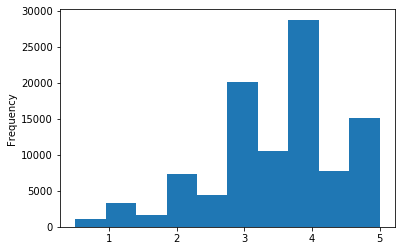
"></div>
  
</details>

In [ ]:
# Câu 2: Vẽ biểu đồ bar plot cột 'rating' của ratings


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div class="output_subarea output_png"><img src="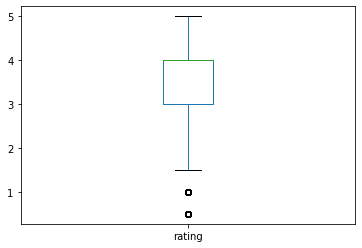
"></div>
  
</details>

In [ ]:
# Câu 3: Dựa vào Câu 9 - Part 5, Vẽ biểu đồ plot() cho 20 dòng đầu của yearly_average sau khi sắp tăng dần


<details>
  <summary>Nhấn vào đây để xem kết quả!</summary>
  <div class="output_subarea output_png"><img src="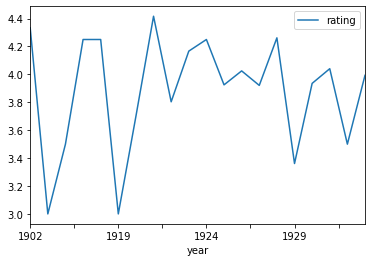
"></div>
  
</details>

#### Quan sát biểu đồ trên, nhận xét:
 - Những năm nào có rating đặc biệt cao/thấp?